In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

Seoul Bike Sharing Demand [dataset]. 2020. UCI Machine Learning Repository. Available from: https://doi.org/10.24432/C5F62R.

In [20]:
dataset_cols= ["bike_count", "hour", "temp", "humidity", "wind_speed", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional" ]
df= pd.read_csv("SeoulBikeData.csv", encoding='latin1').drop(["Date", "Holiday", "Seasons"], axis=1)

In [21]:
df

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Yes
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Yes
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Yes
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Yes


In [22]:
df.columns = dataset_cols
df["functional"] = (df["functional"]=="Yes").astype(int)
df= df.drop(["hour"], axis=1)
print("DataFrame columns after renaming and dropping 'hour':")
print(df.columns)

In [23]:
df.head()

,bike_count,temp,humidity,wind_speed,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1


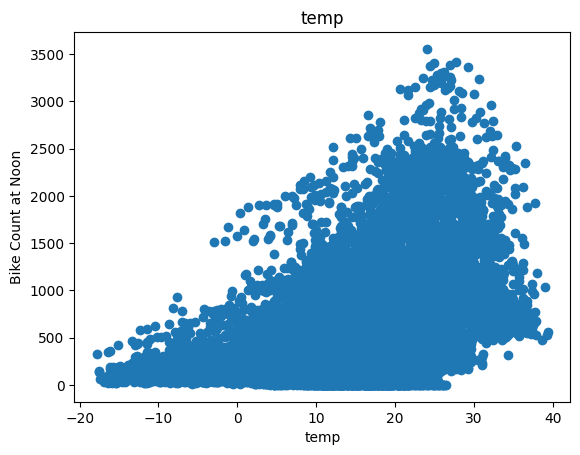

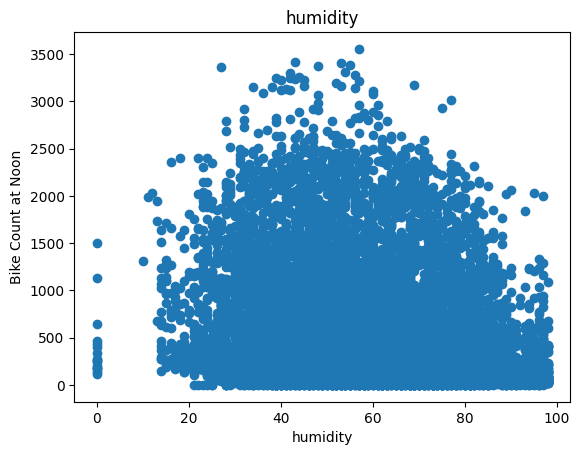

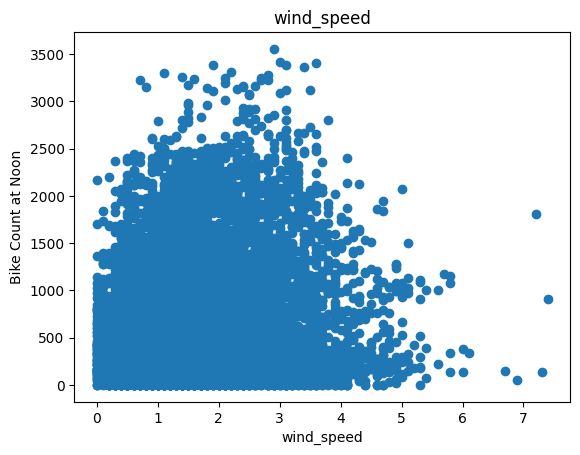

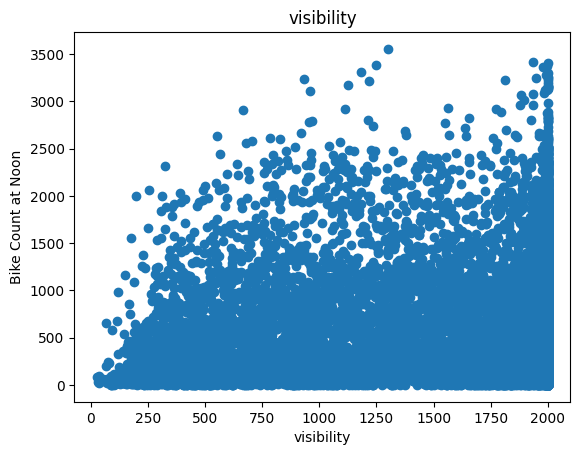

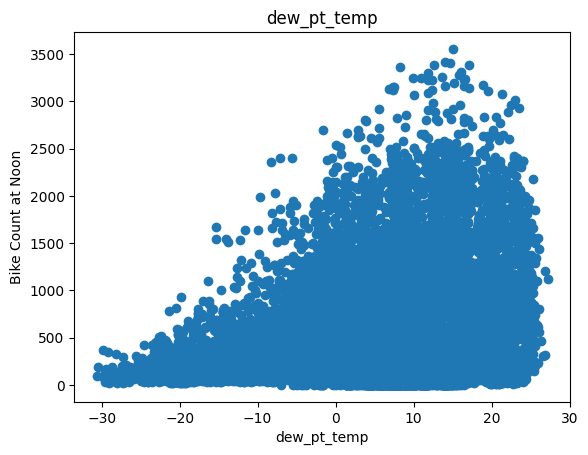

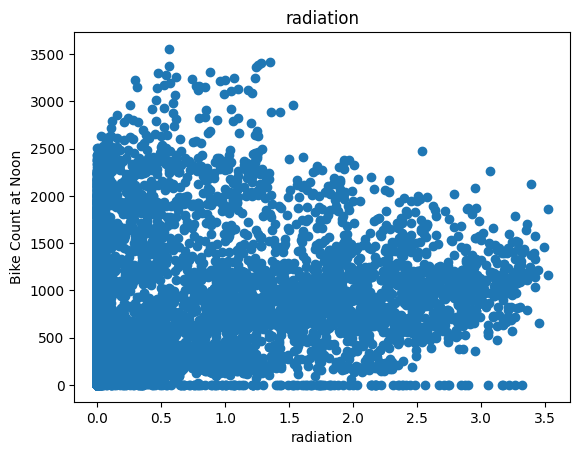

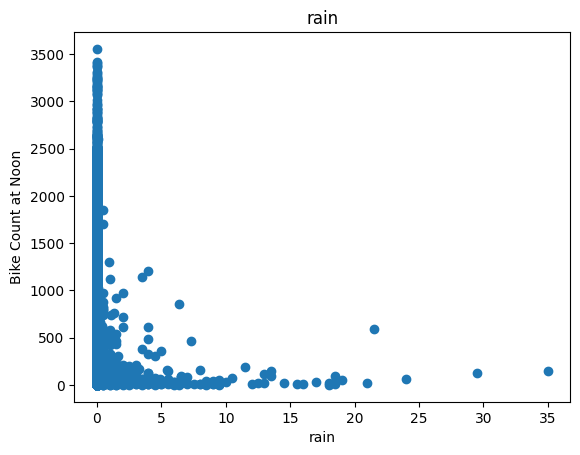

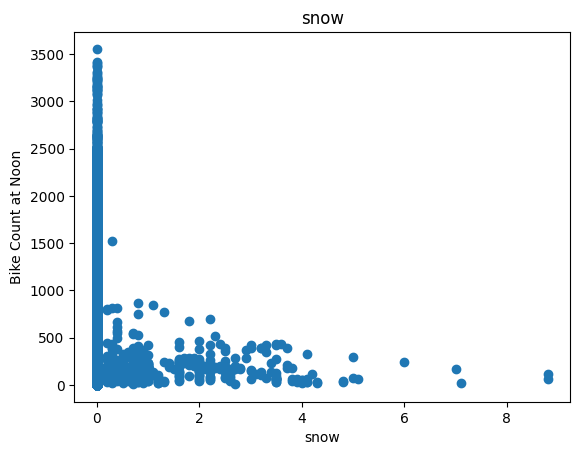

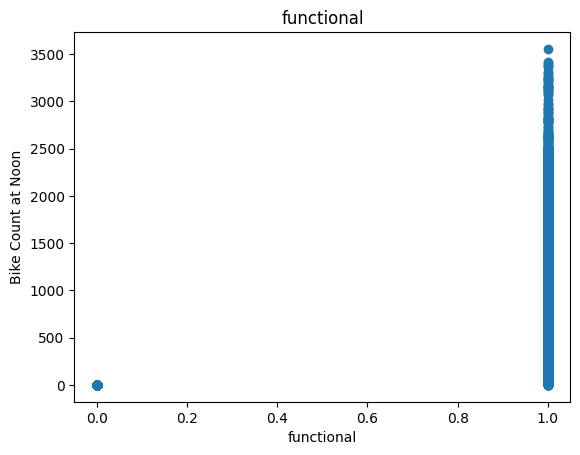

In [24]:
for label in df.columns[1:]:
  plt.scatter(df[label], df["bike_count"])
  plt.title(label)
  plt.ylabel("Bike Count at Noon")
  plt.xlabel(label)
  plt.show()

In [25]:
df=df.drop(["visibility", "functional"], axis=1)

In [26]:
df.head()

,bike_count,temp,humidity,wind_speed,dew_pt_temp,radiation,rain,snow
0,254,-5.2,37,2.2,-17.6,0.0,0.0,0.0
1,204,-5.5,38,0.8,-17.6,0.0,0.0,0.0
2,173,-6.0,39,1.0,-17.7,0.0,0.0,0.0
3,107,-6.2,40,0.9,-17.6,0.0,0.0,0.0
4,78,-6.0,36,2.3,-18.6,0.0,0.0,0.0


# Train/valid/test dataset

In [27]:
train, val, test= np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [28]:
def get_xy(dataframe, y_label, x_labels=None):
  dataframe= copy.deepcopy(dataframe)
  if x_labels is None:
    X= dataframe[[c for c in dataframe.columns if c!= y_label]].values
  else:
    if len(x_labels)==1:
      X= dataframe[x_labels[0]].values.reshape(-1,1)
    else:
      X= dataframe[x_labels].values

  Y= dataframe[y_label].values.reshape(-1,1)
  data= np.hstack((X, Y))

  return data, X, Y



In [29]:
_, X_train_temp, Y_train_temp= get_xy(train, "bike_count", x_labels=["temp"])
_, X_val_temp, Y_val_temp= get_xy(val, "bike_count", x_labels=["temp"])
_, X_test_temp, Y_test_temp= get_xy(test, "bike_count", x_labels=["temp"])

In [30]:
X_train_temp

array([[14.6],
       [26.8],
       [-5.7],
       ...,
       [12.8],
       [11.8],
       [ 2.7]])

In [31]:
temp_reg= LinearRegression()
temp_reg.fit(X_train_temp, Y_train_temp)

LinearRegression()

In [32]:
print(temp_reg.coef_, temp_reg.intercept_)

[[29.07126109]] [330.32052448]


In [33]:
temp_reg.score(X_test_temp, Y_test_temp)

0.2802092086481077

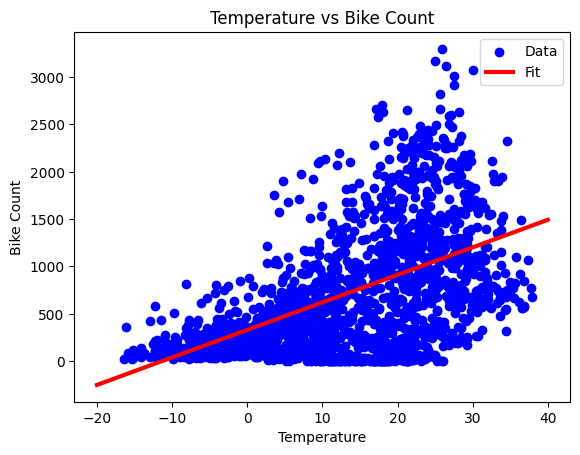

In [34]:
plt.scatter(X_test_temp, Y_test_temp, label="Data", color="blue")
x= np.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1,1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Temperature vs Bike Count")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.show()

# Multiple Linear Regresssion

In [35]:
df.columns

Index(['bike_count', 'temp', 'humidity', 'wind_speed', 'dew_pt_temp',
       'radiation', 'rain', 'snow'],
      dtype='object')

In [36]:
train, val, test= np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])
_, X_train_all, Y_train_all= get_xy(train, "bike_count", x_labels=df.columns[1:])
_, X_val_all, Y_val_all= get_xy(val, "bike_count", x_labels=df.columns[1:])
_, X_test_all, Y_test_all= get_xy(test, "bike_count", x_labels=df.columns[1:])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [37]:
all_reg= LinearRegression()
all_reg.fit(X_train_all, Y_train_all)

LinearRegression()

In [38]:
all_reg.score(X_test_all, Y_test_all)

0.39916181826039654

In [65]:
y_pred_lr=all_reg.predict(X_test_all)

# Regression with Neural Net

In [39]:
temp_normalizer= tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
temp_nn_model= tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])

In [41]:
temp_nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.01), loss= tf.keras.losses.MeanSquaredError())

In [42]:
# Assuming X_train_temp and X_val_temp (as they currently exist in the environment)
# are multi-feature arrays and the 'temp' feature is the first column.
# We extract the 'temp' feature and reshape to (num_samples, 1) for the single-feature model.
X_train_temp_single_feature = X_train_temp[:, 0].reshape(-1, 1)
X_val_temp_single_feature = X_val_temp[:, 0].reshape(-1, 1)

history= temp_nn_model.fit(X_train_temp_single_feature, Y_train_temp, verbose=0, epochs=100, validation_data=(X_val_temp_single_feature, Y_val_temp))

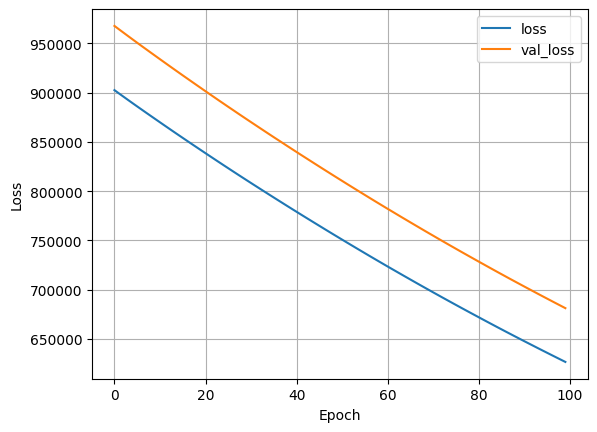

In [43]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)
  plt.show()

plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


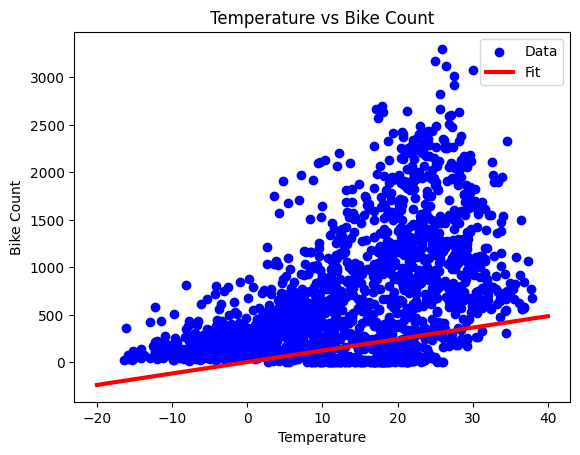

In [44]:
plt.scatter(X_test_temp[:, 0], Y_test_temp, label="Data", color="blue")
x= np.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1,1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Temperature vs Bike Count")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.show()

# Neural Net

In [52]:
new_temp_normalizer= tf.keras.layers.Normalization(input_shape=(1,), axis=None)
new_temp_normalizer.adapt(X_train_temp[:, 0].reshape(-1))

nn_model= tf.keras.Sequential([
    new_temp_normalizer,
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001), loss= tf.keras.losses.MeanSquaredError())

In [53]:
history= nn_model.fit(X_train_temp[:, 0].reshape(-1, 1), Y_train_temp, verbose=0, epochs=100, validation_data=(X_val_temp[:, 0].reshape(-1, 1), Y_val_temp))

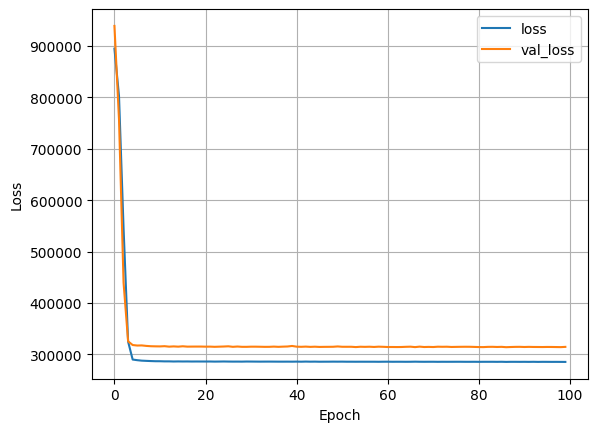

In [54]:
plot_loss(history)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


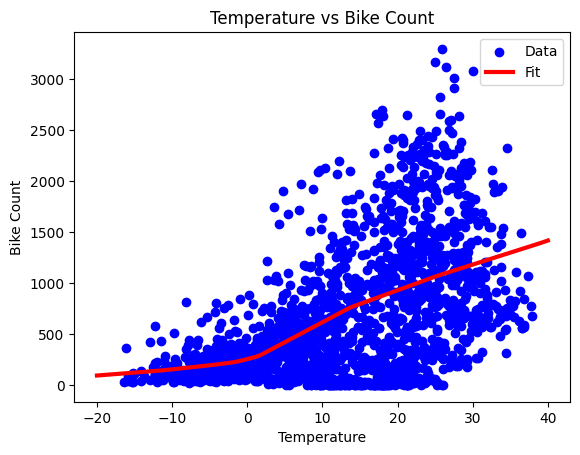

In [55]:
plt.scatter(X_test_temp[:, 0], Y_test_temp, label="Data", color="blue")
x= np.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(np.array(x).reshape(-1,1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Temperature vs Bike Count")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.show()

In [60]:
all_normalizer= tf.keras.layers.Normalization(input_shape=(7,), axis=-1)
all_normalizer.adapt(X_train_all)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
nn_model= tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001), loss= tf.keras.losses.MeanSquaredError())

In [62]:
history= nn_model.fit(X_train_all, Y_train_all, verbose=0, epochs=100, validation_data=(X_val_all, Y_val_all))

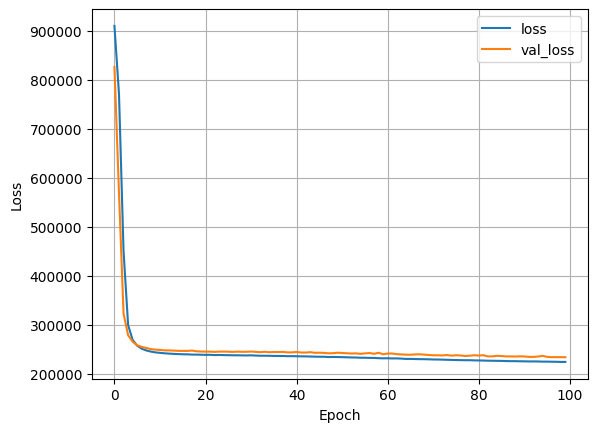

In [63]:
plot_loss(history)

In [66]:
# calculate the MSG for both linear reg and nn
y_pred_lr=all_reg.predict(X_test_all)
y_pred_nn= nn_model.predict(X_test_all)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [67]:
def MSE(y_pred, y_real):
  return np.square(y_pred-y_real).mean()

In [70]:
MSE(y_pred_lr, Y_test_all)

np.float64(254650.6484355798)

In [71]:
MSE(y_pred_nn, Y_test_all)

np.float64(227235.93883316676)

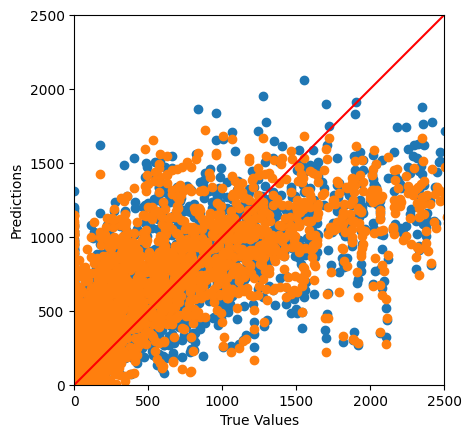

In [74]:
ax= plt.axes(aspect='equal')
plt.scatter(Y_test_all, y_pred_nn, label="NN")
plt.scatter(Y_test_all, y_pred_lr, label="LR")
plt.xlabel("True Values")
plt.ylabel("Predictions")
lims= [0, 2500]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims, c="red")